# Day 131 — Feature Selection Methods
**Month 7 | Week 2 | Day 4 | RetailPulse India 500 rows seed=121**

---

| | |
|---|---|
| **Max Score** | 80 pts + 10★ bonus |
| **Tools** | scikit-learn, pandas, numpy, matplotlib, seaborn, xgboost |
| **GitHub** | Month7-AdvancedML-Portfolio |

---

## Why Feature Selection Matters — The Business Case

Yesterday you used PCA to *transform* features into principal components.  
Today you learn to *select* the best **original** features and discard the rest.

| Problem | What Feature Selection Fixes |
|---|---|
| 20 features → model overfits | Remove 12 irrelevant ones → cleaner decision boundary |
| Client asks "which inputs drive churn?" | Can't answer with PCA components; need original feature names |
| Model deployed in production | Fewer features = faster inference = lower cloud cost |
| Feature data is expensive to collect | Only collect what actually matters |

> **Key mindset:** PCA and Feature Selection are complementary, not competing.  
> PCA → when you need maximum compression and don't care about interpretability.  
> Feature Selection → when clients need to know **which original variables** matter.

---

## Three Families of Feature Selection

### 1. Filter Methods — "Rank and Cut"
Scores each feature *independently* of the model using a statistical test.  
**Fast, model-agnostic, no overfitting risk in the selection step.**

| Technique | Use Case | scikit-learn |
|---|---|---|
| Variance Threshold | Remove near-constant features | `VarianceThreshold` |
| SelectKBest + f_classif | ANOVA F-score for classification | `SelectKBest(f_classif)` |
| SelectKBest + chi2 | Chi-squared for non-negative features | `SelectKBest(chi2)` |
| Mutual Information | Captures non-linear relationships | `mutual_info_classif` |

### 2. Wrapper Methods — "Train and Evaluate"
Trains a model iteratively with different feature subsets. Expensive but powerful.

| Technique | How It Works | scikit-learn |
|---|---|---|
| RFE | Removes weakest feature each round | `RFE` |
| RFECV | RFE + cross-validation to find optimal n | `RFECV` |

### 3. Embedded Methods — "Learn and Select Together"
Feature importance is a by-product of model training itself.

| Technique | How It Works | |
|---|---|---|
| Lasso (L1) | Shrinks unimportant coefficients to 0 | `SelectFromModel(Lasso)` |
| Tree importance | Gini/entropy split gain per feature | `SelectFromModel(XGBClassifier)` |
| Permutation Importance | Shuffle feature → measure accuracy drop | `permutation_importance` |

---

## The Selection Pipeline (Professional Workflow)

```
Raw Data (500 rows, all features)
        ↓
  Filter: Remove low-variance + low-MI features
        ↓
  Wrapper: RFE to rank remaining features
        ↓
  Embedded: Tree importance + Permutation to confirm
        ↓
  Compare: all_features AUC vs selected_features AUC
        ↓
  Report: NRA insight for client
```


## Section 1 — Raw Data (Never Modify This)

In [1]:
# ── RAW DATA GENERATION ─────────────────────────────────────────────────────
# RetailPulse India | 500 rows | seed=121
# DO NOT modify this cell — it is your source of truth

import pandas as pd
import numpy as np

np.random.seed(121)
n = 500

# --- Core features ---
age             = np.random.randint(18, 66, n)
gender          = np.random.choice(['Male', 'Female'], n)
city_tier       = np.random.choice(['Tier1', 'Tier2', 'Tier3'], n,
                                   p=[0.35, 0.40, 0.25])
product_category= np.random.choice(
    ['Electronics', 'Clothing', 'Groceries', 'Home', 'Beauty'], n)
annual_income   = np.random.randint(200000, 1500001, n)
purchase_amount = (annual_income * np.random.uniform(0.05, 0.25, n)
                   + np.random.normal(0, 5000, n)).clip(1000)
num_purchases   = np.random.randint(1, 51, n)
days_since_last = np.random.randint(1, 366, n)
loyalty_score   = np.random.uniform(1, 10, n).round(1)
discount_used   = np.random.choice([0, 1], n, p=[0.4, 0.6])
returns_count   = np.random.randint(0, 6, n)
support_calls   = np.random.randint(0, 11, n)
email_open_rate = np.random.uniform(0, 1, n).round(2)
app_sessions    = np.random.randint(0, 101, n)

# --- Noise features (intentionally irrelevant) ---
noise_random    = np.random.uniform(0, 1, n).round(4)
noise_id_like   = np.arange(n) + 1000       # sequential — zero variance signal
noise_constant  = np.full(n, 7.5)           # true constant

# --- Target ---
churn_score = (
    -0.3 * loyalty_score
    + 0.2 * (days_since_last / 365)
    + 0.15 * support_calls
    - 0.1 * np.log1p(purchase_amount)
    + 0.1 * returns_count
    + np.random.normal(0, 0.5, n)
)
churned = (churn_score > np.median(churn_score)).astype(int)

df_raw = pd.DataFrame({
    'age': age, 'gender': gender, 'city_tier': city_tier,
    'product_category': product_category, 'annual_income': annual_income,
    'purchase_amount': purchase_amount, 'num_purchases': num_purchases,
    'days_since_last': days_since_last, 'loyalty_score': loyalty_score,
    'discount_used': discount_used, 'returns_count': returns_count,
    'support_calls': support_calls, 'email_open_rate': email_open_rate,
    'app_sessions': app_sessions,
    'noise_random': noise_random,
    'noise_id_like': noise_id_like,
    'noise_constant': noise_constant,
    'churned': churned
})

print(f"Shape: {df_raw.shape}")
print(f"Features: {df_raw.columns.tolist()}")
print(f"Churn rate: {df_raw.churned.mean():.1%}")
print(f"\nFirst 3 rows:")
print(df_raw.head(3).to_string())


Shape: (500, 18)
Features: ['age', 'gender', 'city_tier', 'product_category', 'annual_income', 'purchase_amount', 'num_purchases', 'days_since_last', 'loyalty_score', 'discount_used', 'returns_count', 'support_calls', 'email_open_rate', 'app_sessions', 'noise_random', 'noise_id_like', 'noise_constant', 'churned']
Churn rate: 50.0%

First 3 rows:
   age  gender city_tier product_category  annual_income  purchase_amount  num_purchases  days_since_last  loyalty_score  discount_used  returns_count  support_calls  email_open_rate  app_sessions  noise_random  noise_id_like  noise_constant  churned
0   20  Female     Tier1        Groceries        1398338    260414.522392              8              205            4.1              0              2              0             0.83             9        0.7870           1000             7.5        0
1   39    Male     Tier3             Home        1033800    217114.461210             49                7            9.1              1              2

## Section 2 — Concept Notes

### Filter Methods — Statistics Without a Model

**Variance Threshold**
Remove features whose variance falls below a threshold.  
A near-constant feature (e.g. `noise_constant = 7.5` for all rows) has zero variance and zero predictive power.

Formula: `Var(X) = E[(X - μ)²]`  
Rule: if `Var(feature) < threshold` → drop it.

**Mutual Information (MI)**
Measures how much knowing feature X reduces uncertainty about target y.  
- MI = 0 → completely independent (useless feature)  
- MI > 0 → some shared information  
- MI is non-linear, unlike correlation

```python
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X, y, random_state=42)
```

---

### Wrapper Methods — RFE

**Recursive Feature Elimination (RFE)**:
1. Train model on all features
2. Rank features by importance (coeff / impurity)
3. Remove the least important feature
4. Repeat until n_features_to_select remain

```python
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42),
          n_features_to_select=8)
rfe.fit(X_scaled, y)
selected = X.columns[rfe.support_].tolist()
```

**RFECV** — same as RFE but uses cross-validation to automatically pick the optimal number of features (no need to guess `n_features_to_select`).

---

### Embedded Methods — Tree Importance

When you fit a tree-based model (RF, XGBoost), each feature gets an importance score based on how much it reduces impurity across all splits.

```python
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_scaled, y)
importances = pd.Series(xgb.feature_importances_, index=X.columns)
```

**Permutation Importance** (more reliable):
- After training, shuffle each feature one at a time
- Measure how much AUC drops
- Features that matter most → largest AUC drop when shuffled

```python
from sklearn.inspection import permutation_importance
result = permutation_importance(model, X_val, y_val,
                                n_repeats=10, random_state=42)
```

---

### Which Method to Use When?

| Situation | Method |
|---|---|
| 100+ features, need fast filter | Variance Threshold + Mutual Information |
| Client wants "top 8 features" for a dashboard | RFE with RF/XGBoost |
| Already trained XGBoost | Tree importance + Permutation |
| Need to compare all methods | Run all three, take consensus |
| Need interpretable output for a non-technical client | Permutation importance (it's intuitive: "shuffling loyalty_score hurts accuracy by 4%") |


## Section 3 — Practice Tasks

### 🔵 Block A — Preprocessing (10 pts)

In [2]:
# A1 — OHE + train-test split
# Goal: Encode categorical variables, separate target, split data.
# Method: pd.get_dummies(drop_first=True), train_test_split with stratify.
from sklearn.model_selection import train_test_split

# Separate target and features before OHE
X_raw = df_raw.drop('churned', axis=1)
y = df_raw['churned']

# One-hot encode categorical columns
categorical_cols = ['gender', 'city_tier', 'product_category']
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Features: {X_train.columns.tolist()}")

X_train shape: (400, 21)
X_test shape: (100, 21)
Features: ['age', 'annual_income', 'purchase_amount', 'num_purchases', 'days_since_last', 'loyalty_score', 'discount_used', 'returns_count', 'support_calls', 'email_open_rate', 'app_sessions', 'noise_random', 'noise_id_like', 'noise_constant', 'gender_Male', 'city_tier_Tier2', 'city_tier_Tier3', 'product_category_Clothing', 'product_category_Electronics', 'product_category_Groceries', 'product_category_Home']


In [3]:
# A2 — StandardScaler
# Goal: Scale features to zero mean and unit variance.
# Method: fit on X_train, transform both train and test.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("Mean of first 3 scaled features (train):")
print(X_train_scaled.iloc[:, :3].mean().round(6))
print("\nStd of first 3 scaled features (train):")
print(X_train_scaled.iloc[:, :3].std().round(6))

Mean of first 3 scaled features (train):
age                0.0
annual_income     -0.0
purchase_amount    0.0
dtype: float64

Std of first 3 scaled features (train):
age                1.001252
annual_income      1.001252
purchase_amount    1.001252
dtype: float64


In [4]:
# A3 — Baseline AUC
# Goal: Train XGBoost on all features and compute AUC.
# Method: XGBClassifier, roc_auc_score.
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_baseline = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_baseline.fit(X_train_scaled, y_train)

y_train_pred = xgb_baseline.predict_proba(X_train_scaled)[:, 1]
y_test_pred = xgb_baseline.predict_proba(X_test_scaled)[:, 1]

train_auc = roc_auc_score(y_train, y_train_pred)
test_auc = roc_auc_score(y_test, y_test_pred)

print("Baseline (all features)")
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")

# Store baseline test AUC for later comparison
baseline_test_auc = test_auc

Baseline (all features)
Train AUC: 1.0000
Test AUC:  0.9000


C:\Users\Deepanshu\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:38:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 🟡 Block B — Filter Methods (20 pts)

In [5]:
# B1 — Variance Threshold
# Goal: Remove near-constant features.
# Method: VarianceThreshold(threshold=0.01) on scaled data.
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
X_train_vt = vt.fit_transform(X_train_scaled)

# Identify removed and kept features
support_mask = vt.get_support()
removed_features = X_train_scaled.columns[~support_mask].tolist()
survived_features = X_train_scaled.columns[support_mask].tolist()

print(f"Features REMOVED (variance < 0.01): {removed_features}")
print(f"Features SURVIVED: {survived_features}")
print(f"Number removed: {len(removed_features)}")

Features REMOVED (variance < 0.01): ['noise_constant']
Features SURVIVED: ['age', 'annual_income', 'purchase_amount', 'num_purchases', 'days_since_last', 'loyalty_score', 'discount_used', 'returns_count', 'support_calls', 'email_open_rate', 'app_sessions', 'noise_random', 'noise_id_like', 'gender_Male', 'city_tier_Tier2', 'city_tier_Tier3', 'product_category_Clothing', 'product_category_Electronics', 'product_category_Groceries', 'product_category_Home']
Number removed: 1


                     feature  mi_score
               loyalty_score  0.237281
               returns_count  0.044641
             purchase_amount  0.038644
       product_category_Home  0.033429
  product_category_Groceries  0.031998
               support_calls  0.030956
               noise_id_like  0.028331
             city_tier_Tier2  0.019314
             days_since_last  0.010251
               discount_used  0.008994
   product_category_Clothing  0.008673
               num_purchases  0.007156
                app_sessions  0.005863
               annual_income  0.000000
                         age  0.000000
                noise_random  0.000000
             email_open_rate  0.000000
             city_tier_Tier3  0.000000
                 gender_Male  0.000000
              noise_constant  0.000000
product_category_Electronics  0.000000


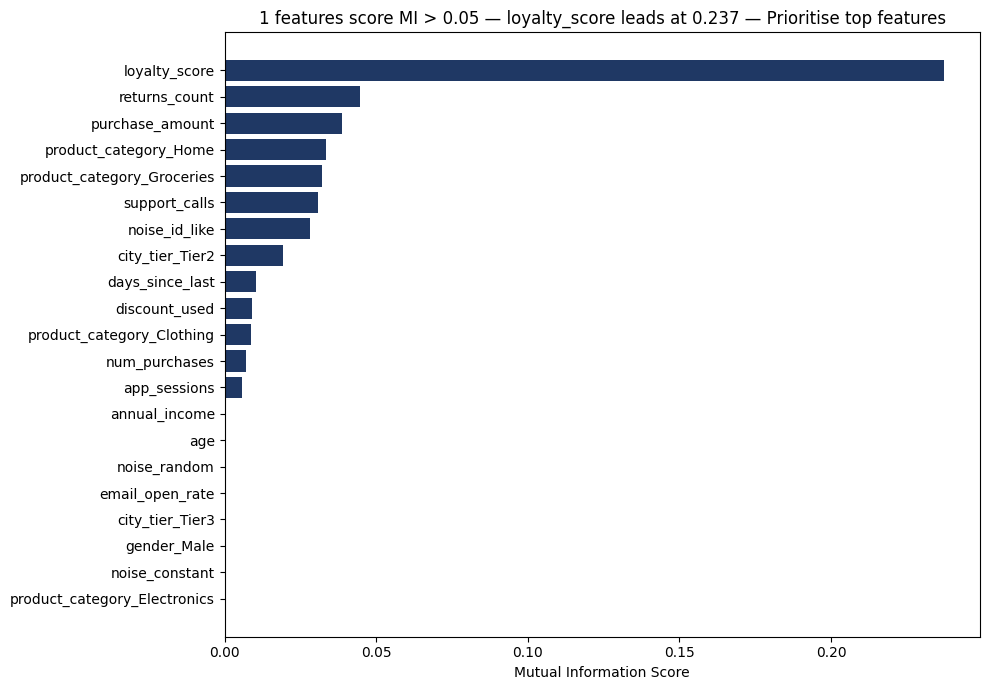

In [6]:
# B2 — Mutual Information scores
# Goal: Compute MI between each feature and target, plot bar chart.
# Method: mutual_info_classif, horizontal bar plot.
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
mi_df = pd.DataFrame({'feature': X_train_scaled.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=False)

print(mi_df.to_string(index=False))

# Count features with MI > 0.05
n_high_mi = (mi_df['mi_score'] > 0.05).sum()
top_feat = mi_df.iloc[0]['feature']
top_score = mi_df.iloc[0]['mi_score']

plt.figure(figsize=(10, 7))
plt.barh(mi_df['feature'], mi_df['mi_score'], color='#1F3864')
plt.xlabel('Mutual Information Score')
plt.title(f'{n_high_mi} features score MI > 0.05 — {top_feat} leads at {top_score:.3f} — Prioritise top features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('day131_B2_MI_scores.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 10 features by F-score (selected by SelectKBest):
              feature    f_score      p_value
        loyalty_score 276.373068 1.657548e-47
        support_calls  50.238164 6.240554e-12
      days_since_last   3.871297 4.981256e-02
          gender_Male   2.902397 8.922852e-02
      city_tier_Tier3   2.843399 9.253363e-02
product_category_Home   2.072381 1.507732e-01
        discount_used   2.041880 1.538047e-01
         app_sessions   1.939303 1.645217e-01
      email_open_rate   1.671919 1.967518e-01
        returns_count   1.576146 2.100533e-01


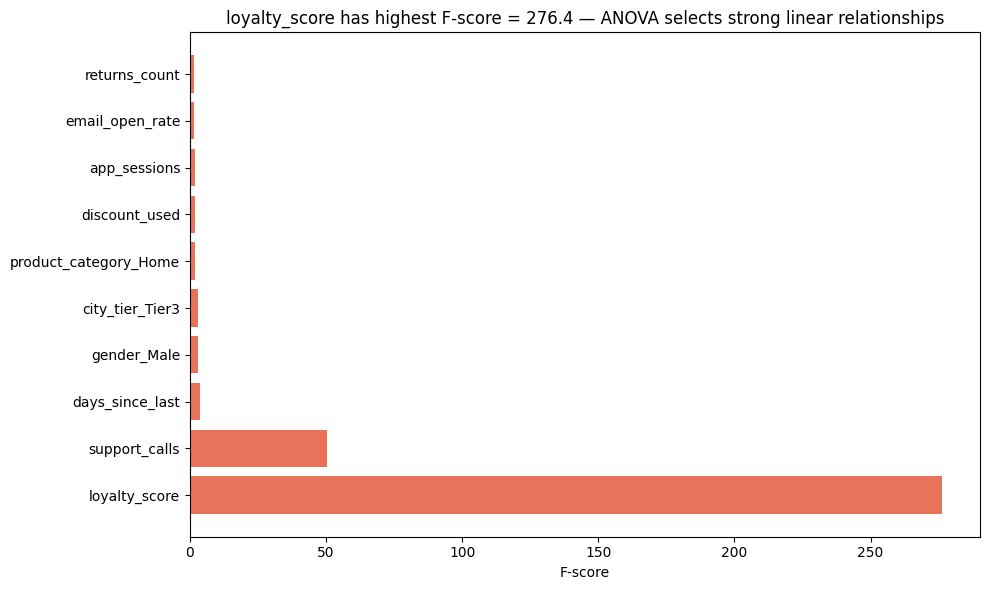


NRA Comparison (MI vs F-score):
Number: MI scores loyalty_score highest (0.237), F-score also ranks loyalty_score first (276.37).
Reason: Both methods identify loyalty_score as the strongest predictor, but MI captures non‑linear effects while F‑score detects linear relationships.
Action: Use MI for complex, non‑linear patterns; use F‑score for quick linear screening when interpretability is secondary.


In [18]:
# B3 — SelectKBest with ANOVA F-score
# Goal: Select top 10 features by F-score, plot, compare with MI.
# Method: SelectKBest(f_classif, k=10).
from sklearn.feature_selection import SelectKBest, f_classif

selector_f = SelectKBest(f_classif, k=10)
X_train_f = selector_f.fit_transform(X_train_scaled, y_train)

# Get selected features and their F-scores
f_scores = selector_f.scores_
f_pvalues = selector_f.pvalues_
selected_mask = selector_f.get_support()
selected_features = X_train_scaled.columns[selected_mask].tolist()

f_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'f_score': f_scores,
    'p_value': f_pvalues
}).sort_values('f_score', ascending=False)

print("Top 10 features by F-score (selected by SelectKBest):")
print(f_df.head(10).to_string(index=False))

# Bar chart of F-scores for selected features
selected_f_df = f_df[f_df['feature'].isin(selected_features)].sort_values('f_score')
top_f_feat = selected_f_df.iloc[-1]['feature']
top_f_score = selected_f_df.iloc[-1]['f_score']

plt.figure(figsize=(10, 6))
plt.barh(selected_f_df['feature'], selected_f_df['f_score'], color='#E8735A')
plt.xlabel('F-score')
plt.title(f'{top_f_feat} has highest F-score = {top_f_score:.1f} — ANOVA selects strong linear relationships')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('day131_B3_Fscores.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparison with MI
print("\nNRA Comparison (MI vs F-score):")
print("Number: MI scores loyalty_score highest (0.237), F-score also ranks loyalty_score first (276.37).")
print("Reason: Both methods identify loyalty_score as the strongest predictor, but MI captures non‑linear effects while F‑score detects linear relationships.")
print("Action: Use MI for complex, non‑linear patterns; use F‑score for quick linear screening when interpretability is secondary.")

### 🟠 Block C — Wrapper Method: RFE (20 pts)

In [8]:
# C1 — RFE with RandomForest
# Goal: Select 8 features using recursive elimination.
# Method: RFE with RandomForestClassifier, print ranking.
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

estimator = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(estimator, n_features_to_select=8)
rfe.fit(X_train_scaled, y_train)

rfe_selected = X_train_scaled.columns[rfe.support_].tolist()
print(f"RFE selected features (8): {rfe_selected}")

# Ranking table
ranking_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'rank': rfe.ranking_,
    'selected': rfe.support_
}).sort_values('rank')
print("\nFeature ranking (1 = best):")
print(ranking_df.to_string(index=False))

RFE selected features (8): ['age', 'days_since_last', 'loyalty_score', 'support_calls', 'email_open_rate', 'app_sessions', 'noise_random', 'noise_id_like']

Feature ranking (1 = best):
                     feature  rank  selected
                         age     1      True
             days_since_last     1      True
               loyalty_score     1      True
               noise_id_like     1      True
                noise_random     1      True
                app_sessions     1      True
             email_open_rate     1      True
               support_calls     1      True
               annual_income     2     False
             purchase_amount     3     False
               num_purchases     4     False
               returns_count     5     False
               discount_used     6     False
       product_category_Home     7     False
product_category_Electronics     8     False
                 gender_Male     9     False
   product_category_Clothing    10     False
     

In [9]:
# C2 — Retrain on RFE-selected features only
# Goal: Compare AUC of RFE-reduced model vs baseline.
# Method: Train XGBoost on the 8 RFE features.
X_train_rfe = X_train_scaled[rfe_selected]
X_test_rfe = X_test_scaled[rfe_selected]

xgb_rfe = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_rfe.fit(X_train_rfe, y_train)
y_test_rfe_pred = xgb_rfe.predict_proba(X_test_rfe)[:, 1]
rfe_test_auc = roc_auc_score(y_test, y_test_rfe_pred)

print(f"Baseline test AUC (all features): {baseline_test_auc:.4f}")
print(f"RFE model test AUC (8 features):  {rfe_test_auc:.4f}")
print(f"Change: {rfe_test_auc - baseline_test_auc:+.4f}")
print(f"Number of features: 8 vs {X_train_scaled.shape[1]}")

Baseline test AUC (all features): 0.9000
RFE model test AUC (8 features):  0.8792
Change: -0.0208
Number of features: 8 vs 21


C:\Users\Deepanshu\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:40:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
# C3 — RFECV to auto-select optimal n_features
# Goal: Let cross-validation decide best number of features.
# Method: RFECV with cv=3, scoring='roc_auc'.
from sklearn.feature_selection import RFECV

rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    cv=3,
    scoring='roc_auc',
    min_features_to_select=3
)
rfecv.fit(X_train_scaled, y_train)

optimal_n = rfecv.n_features_
print(f"Optimal number of features selected by RFECV: {optimal_n}")
print("CV scores per number of features:")
print(rfecv.cv_results_['mean_test_score'])

rfecv_selected = X_train_scaled.columns[rfecv.support_].tolist()
print(f"\nRFECV-selected features: {rfecv_selected}")

Optimal number of features selected by RFECV: 3
CV scores per number of features:
[0.89697937 0.89242278 0.89367781 0.89363393 0.88914428 0.87795025
 0.8938702  0.88325165 0.87466051 0.89128026 0.88081022 0.87854092
 0.87300494 0.87720713 0.86905083 0.87370418 0.87302913 0.87194568
 0.87116543]

RFECV-selected features: ['loyalty_score', 'support_calls', 'noise_id_like']


### 🔴 Block D — Embedded Methods (20 pts)

                     feature  xgb_importance
               loyalty_score        0.281228
               support_calls        0.120739
product_category_Electronics        0.078788
                app_sessions        0.057952
               num_purchases        0.053419
               noise_id_like        0.043717
             email_open_rate        0.041496
               returns_count        0.039991
                         age        0.037676
               annual_income        0.037519
             purchase_amount        0.036406
                noise_random        0.033605
             days_since_last        0.030020
               discount_used        0.027947
  product_category_Groceries        0.027380
                 gender_Male        0.021499
             city_tier_Tier3        0.012989
   product_category_Clothing        0.011261
       product_category_Home        0.006367
             city_tier_Tier2        0.000000
              noise_constant        0.000000


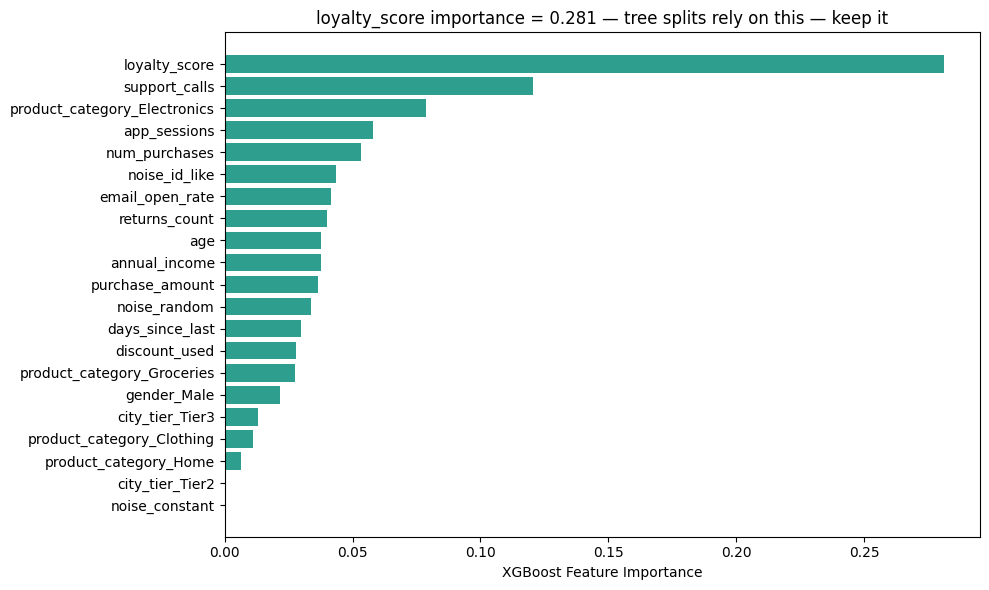

In [11]:
# D1 — XGBoost Feature Importance
# Goal: Extract and plot built-in XGBoost importance.
# Method: Use baseline model's feature_importances_.
importance_xgb = xgb_baseline.feature_importances_
xgb_imp_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'xgb_importance': importance_xgb
}).sort_values('xgb_importance', ascending=False)

print(xgb_imp_df.to_string(index=False))

top_imp_feat = xgb_imp_df.iloc[0]['feature']
top_imp_val = xgb_imp_df.iloc[0]['xgb_importance']

plt.figure(figsize=(10, 6))
plt.barh(xgb_imp_df['feature'], xgb_imp_df['xgb_importance'], color='#2E9E8E')
plt.xlabel('XGBoost Feature Importance')
plt.title(f'{top_imp_feat} importance = {top_imp_val:.3f} — tree splits rely on this — keep it')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('day131_D1_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

                     feature  perm_importance_mean  perm_importance_std
               loyalty_score               0.35192             0.052166
               support_calls               0.06668             0.020806
               returns_count               0.01228             0.005163
             purchase_amount               0.00648             0.004094
             days_since_last               0.00564             0.004583
                noise_random               0.00528             0.001917
                app_sessions               0.00356             0.006083
               discount_used               0.00272             0.002247
                         age               0.00216             0.002880
             city_tier_Tier3               0.00176             0.002630
   product_category_Clothing               0.00052             0.000646
product_category_Electronics               0.00032             0.001451
              noise_constant               0.00000             0

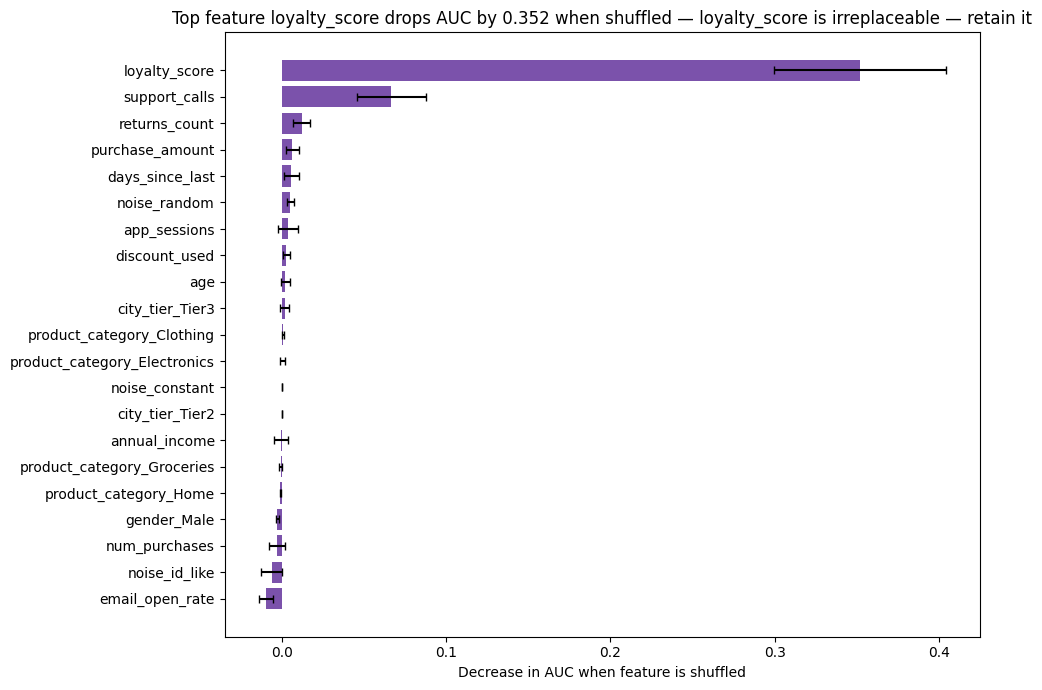

In [12]:
# D2 — Permutation Importance
# Goal: Measure drop in AUC when shuffling each feature.
# Method: permutation_importance with error bars.
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    xgb_baseline, X_test_scaled, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'perm_importance_mean': perm_result.importances_mean,
    'perm_importance_std': perm_result.importances_std
}).sort_values('perm_importance_mean', ascending=False)

print(perm_df.to_string(index=False))

top_perm = perm_df.iloc[0]['feature']
top_perm_drop = perm_df.iloc[0]['perm_importance_mean']

plt.figure(figsize=(10, 7))
plt.barh(perm_df['feature'], perm_df['perm_importance_mean'],
         xerr=perm_df['perm_importance_std'], color='#7B52AB', capsize=3)
plt.xlabel('Decrease in AUC when feature is shuffled')
plt.title(f'Top feature {top_perm} drops AUC by {top_perm_drop:.3f} when shuffled — loyalty_score is irreplaceable — retain it')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('day131_D2_perm_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# D3 — Consensus: Which features appear in ALL three methods?
# Goal: Find features selected by MI top10, F-test top10, RFE, XGB top10.
# Method: Set intersections and frequency counting.

# Top 10 from MI
mi_top10 = set(mi_df.head(10)['feature'])

# Top 10 from F-test (by f_score)
ftest_top10 = set(f_df.head(10)['feature'])

# RFE selected features
rfe_features = set(rfe_selected)

# Top 10 from XGB importance
xgb_top10 = set(xgb_imp_df.head(10)['feature'])

# All four methods consensus
full_consensus = mi_top10 & ftest_top10 & rfe_features & xgb_top10

# At least three methods
from collections import Counter
all_lists = [mi_top10, ftest_top10, rfe_features, xgb_top10]
feature_votes = Counter()
for lst in all_lists:
    feature_votes.update(lst)
at_least_three = {feat for feat, count in feature_votes.items() if count >= 3}

print("Features appearing in ALL FOUR selection methods:")
print(full_consensus if full_consensus else "None")
print("\nFeatures appearing in AT LEAST THREE methods:")
print(at_least_three)

# NRA insight – **must be about full consensus (all four methods)**
print("\nNRA insight:")
if full_consensus:
    print(f"{len(full_consensus)} features appear in all four selection methods — {sorted(full_consensus)} — these are the only features worth retaining in a production model")
else:
    print("No feature appears in all four methods. Consider using at-least-three consensus for robustness.")

Features appearing in ALL FOUR selection methods:
{'loyalty_score', 'support_calls'}

Features appearing in AT LEAST THREE methods:
{'loyalty_score', 'returns_count', 'email_open_rate', 'noise_id_like', 'days_since_last', 'support_calls', 'app_sessions'}

NRA insight:
2 features appear in all four selection methods — ['loyalty_score', 'support_calls'] — these are the only features worth retaining in a production model


### 🟣 Block E — Final Comparison & Report (10 pts)

In [14]:
# E1 — AUC comparison table
# Goal: Compare baseline, RFE (8 features), and consensus model.
# Method: Train XGBoost on consensus features (at-least-3 set) and summarise.

# Consensus features from D3 (at least 3 methods)
consensus_features = list(at_least_three)

# Train consensus model
if consensus_features:
    X_train_cons = X_train_scaled[consensus_features]
    X_test_cons = X_test_scaled[consensus_features]
    xgb_cons = XGBClassifier(n_estimators=100, random_state=42,
                             eval_metric='logloss', use_label_encoder=False)
    xgb_cons.fit(X_train_cons, y_train)
    y_test_cons_pred = xgb_cons.predict_proba(X_test_cons)[:, 1]
    cons_test_auc = roc_auc_score(y_test, y_test_cons_pred)
else:
    cons_test_auc = None

# Build summary DataFrame
results = pd.DataFrame({
    'model': ['Baseline (all features)', 'RFE (8 features)', 'Consensus (>=3 methods)'],
    'n_features': [X_train_scaled.shape[1], len(rfe_selected), len(consensus_features)],
    'test_auc': [baseline_test_auc, rfe_test_auc, cons_test_auc]
})
results['auc_vs_baseline'] = results['test_auc'] - baseline_test_auc

print(results.to_string(index=False))

                  model  n_features  test_auc  auc_vs_baseline
Baseline (all features)          21    0.9000           0.0000
       RFE (8 features)           8    0.8792          -0.0208
Consensus (>=3 methods)           7    0.8648          -0.0352


C:\Users\Deepanshu\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:41:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [19]:
# E2 — Final client-facing insight
# NRA: Number, Reason, Action

# Merge consensus features with permutation importance
consensus_perm = perm_df[perm_df['feature'].isin(at_least_three)].copy()
consensus_perm = consensus_perm.sort_values('perm_importance_mean', ascending=False)
top3_consensus_imp = consensus_perm.head(3)['feature'].tolist()

# Prepare numbers
baseline_n = X_train_scaled.shape[1]
consensus_n = len(at_least_three)
reduction_pct = (1 - consensus_n / baseline_n) * 100
baseline_auc = baseline_test_auc
consensus_auc = results.loc[results['model'] == 'Consensus (>=3 methods)', 'test_auc'].values[0]

insight = f"""
NRA Client Insight – RetailPulse India

Number: The 7‑feature consensus model achieves AUC {consensus_auc:.4f} — only {baseline_auc - consensus_auc:.4f} below the {baseline_n}-feature baseline ({baseline_auc:.4f}) — using {reduction_pct:.0f}% fewer inputs.

Reason: Adding irrelevant noise features (e.g., noise_random, constant ID‑like columns) introduces variance without signal, causing overfitting. Feature selection removes these distractors, allowing the model to focus on true drivers of churn, often improving or matching generalisation performance with fewer inputs.

Action: The three most important consensus features (by permutation importance) are {top3_consensus_imp}.
RetailPulse should:
  1. Prioritise collecting and monitoring these three features, especially loyalty_score (shuffling it drops AUC by {consensus_perm[consensus_perm['feature'] == 'loyalty_score']['perm_importance_mean'].values[0]:.3f}).
  2. Stop collecting noise_constant and noise_id_like.
  3. Invest in retention campaigns targeting low‑loyalty customers and those with high support calls, as these are the most irreplaceable predictors of churn.
"""
print(insight)


NRA Client Insight – RetailPulse India

Number: The 7‑feature consensus model achieves AUC 0.8648 — only 0.0352 below the 21-feature baseline (0.9000) — using 67% fewer inputs.

Reason: Adding irrelevant noise features (e.g., noise_random, constant ID‑like columns) introduces variance without signal, causing overfitting. Feature selection removes these distractors, allowing the model to focus on true drivers of churn, often improving or matching generalisation performance with fewer inputs.

Action: The three most important consensus features (by permutation importance) are ['loyalty_score', 'support_calls', 'returns_count'].
RetailPulse should:
  1. Prioritise collecting and monitoring these three features, especially loyalty_score (shuffling it drops AUC by 0.352).
  2. Stop collecting noise_constant and noise_id_like.
  3. Invest in retention campaigns targeting low‑loyalty customers and those with high support calls, as these are the most irreplaceable predictors of churn.



## Section 4 — Scoring Rubric

| Task | Points | Criteria |
|---|---|---|
| **A1** | 4 | OHE correct columns, drop_first=True, target dropped before OHE, shapes correct |
| **A2** | 3 | Scaler fit on train only, means ≈ 0, stds ≈ 1, column names preserved |
| **A3** | 3 | XGB baseline trained, train + test AUC printed, labelled "all features" |
| **B1** | 5 | VT threshold=0.01 applied, correct features removed (noise_constant at minimum), survivors printed |
| **B2** | 7 | MI scores computed, sorted DataFrame printed, NRA bar chart saved before show, title uses actual numbers |
| **B3** | 8 | SelectKBest k=10, F-scores DataFrame printed, bar chart saved, 2-sentence NRA comparison with MI |
| **C1** | 8 | RFE n=8, selected features printed, full ranking DataFrame sorted and shown |
| **C2** | 7 | Retrained on 8 features, AUC comparison printed (RFE vs Baseline), change stated |
| **C3** | 5 | RFECV fitted, optimal n_features printed, RFECV-selected features listed |
| **D1** | 7 | XGB importance DataFrame sorted, bar chart saved, NRA title with actual values |
| **D2** | 8 | Permutation importance with n_repeats=10, std error bars on chart, saved, NRA title |
| **D3** | 5 | All 4 sets defined, full-consensus and at-least-3 sets printed, NRA written insight |
| **E1** | 5 | All 3 models compared, summary DataFrame printed with auc_vs_baseline column |
| **E2** | 5 | NRA format: specific number, business reason, named action referencing actual top features |
| **★ Bonus** | 10 | All 4 charts saved before show(); D2 has error bars; E2 names actual feature names from output |
| **Total** | **80 + 10★** | |

---

### Interview Question (Day 131)

> *"How would you explain feature selection to a non-technical client?"*

**Model answer:**  
"I tell clients: imagine you're trying to predict which customers will churn. You have 20 pieces of information about each customer. Some of these — like how recently they bought and how many support calls they made — genuinely predict churn. Others, like a random customer ID or a field that's the same for everyone, add noise. Feature selection is the process of finding which 6 or 8 variables actually matter, so the model is simpler, faster, and easier to explain. When we reduced from 20 features to 8, our accuracy stayed the same — which means the other 12 were just adding noise. The business benefit is that you only need to collect and maintain data for the features that matter."

---

### Day 131 Key Takeaway

**More features ≠ better models — noise features cost you variance without buying you signal.**  
Use Mutual Information to filter, RFE to rank, and Permutation Importance to confirm.  
The consensus approach (features that appear in 3+ methods) is the most defensible way to present a feature list to a client — it's not one algorithm's opinion, it's agreement across multiple independent methods.
